# Laboratorio 1 — CH03: Análisis de Algoritmos

Ejercicios de Goodrich, Tamassia & Goldwasser.

## Ejercicio 1 — C-3.50

Sea $p(x)$ un polinomio de grado $n$, es decir,

$$p(x) = \sum_{i=0}^{n} a_i x^i$$

**(a)** Describa un algoritmo simple de tiempo $O(n^2)$ para calcular $p(x)$.

**(b)** Mejore el algoritmo anterior calculando $x^i$ de una forma más eficiente.

**(c)** Ahora considere la siguiente reescritura de $p(x)$:

$$p(x) = a_0 + x\big(a_1 + x\big(a_2 + x\big(a_3 + \cdots + x(a_{n-1} + x a_n)\cdots\big)\big)\big)$$

conocida como el **método de Horner**. Usando la notación big-Oh, caracterice el número de operaciones aritméticas que ejecuta este método.

### (a) Algoritmo $O(n^2)$

In [13]:
def p_cuadratico(a, x):
    suma = 0
    #grado = len(a)-1
    xi = 1
    for i in range(len(a)):
        suma += a[i]*xi
        xi *= x
        
    return suma

In [14]:
p_cuadratico([1,2,3],2)


17

### (b) Algoritmo mejorado

In [15]:
def p_mejorado(a, x):
    resultado = a[0]
    potencia = 1

    for i in range(1, len(a)):
        potencia = potencia * x
        resultado = resultado + a[i] * potencia

    return resultado

### (c) Método de Horner

In [16]:
def horner(a, x):
    suma = a[-2] + x*a[-1]
    a1 = a[:-2]
    for i in a1[::-1]:
        suma = i+ x*suma
    return suma

In [17]:
horner([1,2,3],2)

17

### Verificación de resultados

Los tres algoritmos deben dar el mismo resultado para $p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4$ evaluado en $x=2$.

In [18]:
# a = [a0, a1, a2, a3, a4] -> p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4
a = [3, 2, 5, -1, 4]
x = 2

print("p_cuadratico:", p_cuadratico(a, x))
print("p_mejorado:  ", p_mejorado(a, x))
print("horner:      ", horner(a, x))

p_cuadratico: 83
p_mejorado:   83
horner:       83


## Ejercicio 2 — División sintética

La **división sintética** permite evaluar un polinomio $p(x) = \sum_{i=0}^{n} a_i x^i$ en un valor $x = r$, dividiendo $p(x)$ entre $(x - r)$: el residuo de esa división es exactamente $p(r)$.

Programe una función `division_sintetica(a, r)` que implemente este método para evaluar el polinomio en $r$.

**Pregunta:** ¿es este método igual al método de Horner de la parte (c)? Justifique su respuesta comparando ambos algoritmos.

In [19]:
def division_sintetica(a, r):
    n = len(a) - 1
    resultado = a[n]

    for i in range(n - 1, -1, -1):
        resultado = a[i] + r * resultado

    return resultado


### Verificación

`division_sintetica` debe dar el mismo resultado que `horner` para el mismo polinomio y el mismo valor de evaluación.

In [20]:
print("horner:              ", horner(a, x))
print("division_sintetica:  ", division_sintetica(a, x))

horner:               83
division_sintetica:   83


## Ejercicio 3 — Comparación de algoritmos

El número de operaciones ejecutadas por los algoritmos A y B es $n^2 + n$ y $\dfrac{n^3}{200}$, respectivamente.

Determine $n_0$ tal que A es mejor que B para $n \geq n_0$.

Haga una gráfica (similar a las del notebook `ch03_teoria.ipynb`) que muestre ambas funciones. Ajustar la gráfica como en el cuaderno de teoría.

n0 = 201


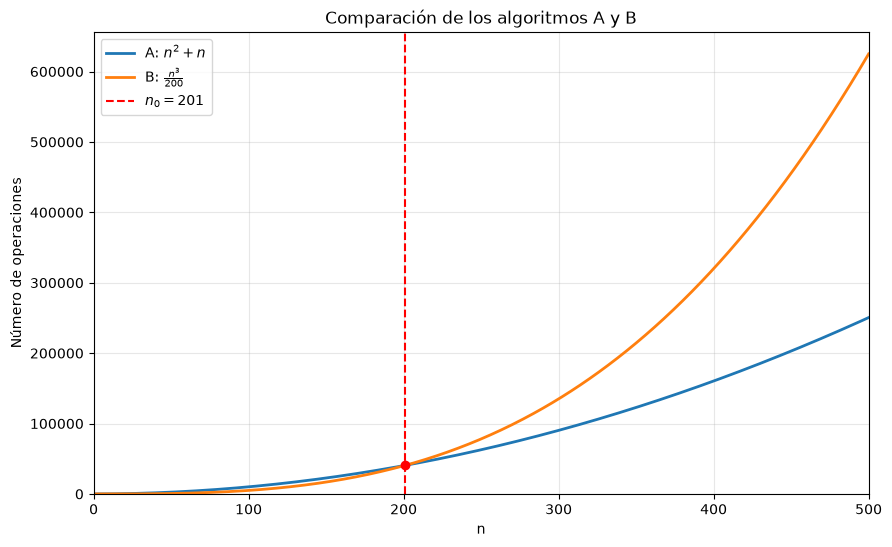

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Funciones
def A(n):
    return n**2 + n

def B(n):
    return n**3 / 200

# Encontrar n0
n = np.arange(1, 1001)

n0 = None
for i in n:
    if A(i) < B(i):
        n0 = i
        break

print("n0 =", n0)

# Valores para la gráfica
x = np.arange(1, 501)

y_A = A(x)
y_B = B(x)

# Gráfica
plt.figure(figsize=(10, 6))

plt.plot(x, y_A, label=r"A: $n^2+n$", linewidth=2)
plt.plot(x, y_B, label=r"B: $\frac{n^3}{200}$", linewidth=2)

# Marcar n0
plt.axvline(n0, color="red", linestyle="--",
            label=rf"$n_0={n0}$")

plt.scatter(n0, A(n0), color="red", zorder=5)

plt.xlabel("n")
plt.ylabel("Número de operaciones")
plt.title("Comparación de los algoritmos A y B")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(0, 500)
plt.ylim(0, max(B(500), A(500)) * 1.05)

plt.show()



## Ejercicio 4 — Three-way set disjointness

Suponiendo que es posible ordenar $n$ números en tiempo $O(n\log n)$, demuestre que es posible resolver el problema de disyunción de tres conjuntos (**three-way set disjointness**) en tiempo $O(n\log n)$.

Programe una función `disjointness_nlogn(A, B, C)` que reciba tres secuencias de tamaño $n$ y retorne `True` si no existe ningún elemento común a las tres, usando ordenamiento en vez de los tres ciclos anidados de la versión $O(n^3)$.

In [22]:
def disjointness_nlogn(A, B, C):
    A = sorted(A)
    B = sorted(B)
    C = sorted(C)

    i = j = k = 0

    while i < len(A) and j < len(B) and k < len(C):
        if A[i] == B[j] == C[k]:
            return False

        minimo = min(A[i], B[j], C[k])

        if A[i] == minimo:
            i += 1
        if B[j] == minimo:
            j += 1
        if C[k] == minimo:
            k += 1

    return True


## Ejercicio 5 — R-3.28

Para cada función $f(n)$ y tiempo $t$ en la siguiente tabla, determine el tamaño más grande $n$ de un problema $P$ que puede resolverse en tiempo $t$ si el algoritmo que resuelve $P$ tarda $f(n)$ microsegundos (una entrada ya está completa).

| $f(n)$ | 1 Segundo | 1 Hora | 1 Mes | 1 Siglo |
|---|---|---|---|---|
| $\log n$ | $\approx 10^{300000}$ | | | |
| $n$ | | | | |
| $n\log n$ | | | | |
| $n^2$ | | | | |
| $2^n$ | | | | |

Complete la tabla. Puede apoyarse en una celda de código para hacer los cálculos.

In [23]:
# Ejercicio 5 - Cálculos

# Todos los tiempos están en microsegundos
segundo = 10**6
hora = 60 * 60 * segundo
mes = 30 * 24 * hora
siglo = 100 * 365 * 24 * hora

print("1 segundo =", segundo)
print("1 hora    =", hora)
print("1 mes     =", mes)
print("1 siglo   =", siglo)

# --------------------------------------------------
# f(n) = log2(n)
# log2(n) <= t  =>  n <= 2^t
# --------------------------------------------------

print("\nlog(n):")
print("1 segundo:", 2**segundo)  # demasiado grande para mostrarlo
print("Exponente en base 10:", segundo * math.log10(2))

# --------------------------------------------------
# f(n) = n
# n <= t
# --------------------------------------------------

print("\nn:")
print("1 segundo:", segundo)
print("1 hora:", hora)
print("1 mes:", mes)
print("1 siglo:", siglo)

# --------------------------------------------------
# f(n) = n log2(n)
# Buscar el mayor n tal que n*log2(n) <= t
# --------------------------------------------------

import math

def max_nlogn(t):
    izquierda = 1
    derecha = t

    while izquierda <= derecha:
        medio = (izquierda + derecha) // 2

        if medio * math.log2(medio) <= t:
            izquierda = medio + 1
        else:
            derecha = medio - 1

    return derecha

print("\nn log(n):")
print("1 segundo:", max_nlogn(segundo))
print("1 hora:", max_nlogn(hora))
print("1 mes:", max_nlogn(mes))
print("1 siglo:", max_nlogn(siglo))

# --------------------------------------------------
# f(n) = n^2
# n^2 <= t  =>  n <= sqrt(t)
# --------------------------------------------------

print("\nn^2:")
print("1 segundo:", math.isqrt(segundo))
print("1 hora:", math.isqrt(hora))
print("1 mes:", math.isqrt(mes))
print("1 siglo:", math.isqrt(siglo))

# --------------------------------------------------
# f(n) = 2^n
# 2^n <= t  =>  n <= log2(t)
# --------------------------------------------------

print("\n2^n:")
print("1 segundo:", math.floor(math.log2(segundo)))
print("1 hora:", math.floor(math.log2(hora)))
print("1 mes:", math.floor(math.log2(mes)))
print("1 siglo:", math.floor(math.log2(siglo)))


1 segundo = 1000000
1 hora    = 3600000000
1 mes     = 2592000000000
1 siglo   = 3153600000000000

log(n):
1 segundo: 

ValueError: Exceeds the limit (4300 digits) for integer string conversion; use sys.set_int_max_str_digits() to increase the limit

## Ejercicio 6 — Valor más frecuente en un rango acotado

Una secuencia $S$ contiene $n$ enteros tomados del intervalo $[0, 4n]$, con repeticiones permitidas.

Describa un algoritmo eficiente para determinar un valor entero $k$ que ocurre con mayor frecuencia en $S$. ¿Cuál es el tiempo de ejecución de su algoritmo?

In [24]:
def valor_mas_frecuente(S, n):
    frecuencias = [0] * (4 * n + 1)

    # Contar cuántas veces aparece cada valor
    for x in S:
        frecuencias[x] += 1

    # Buscar el valor con mayor frecuencia
    k = 0

    for i in range(1, 4 * n + 1):
        if frecuencias[i] > frecuencias[k]:
            k = i

    return k


## Ejercicio 7 — Búsqueda secuencial

Dada una lista $L$ de $n$ elementos (sin ordenar) y un valor $x$, programe una función `busqueda_secuencial(L, x)` que retorne `True` si $x$ se encuentra en $L$ y `False` en caso contrario, recorriendo la lista elemento por elemento.

Analice el mejor y el peor caso de este algoritmo usando notación big-Oh.

In [25]:
def busqueda_secuencial(L, x):
    for elemento in L:
        if elemento == x:
            return True

    return False


## Ejercicio 8 — Búsqueda binaria

Dada una lista $L$ **ordenada** de $n$ elementos y un valor $x$, programe una función `busqueda_binaria(L, x)` que retorne `True` si $x$ se encuentra en $L$ y `False` en caso contrario, descartando en cada paso la mitad de los elementos restantes.

¿Cuál es el tiempo de ejecución de este algoritmo, usando notación big-Oh? Compárelo con el de la búsqueda secuencial del ejercicio anterior.

In [26]:
def busqueda_binaria(L, x):
    izquierda = 0
    derecha = len(L) - 1

    while izquierda <= derecha:
        medio = (izquierda + derecha) // 2

        if L[medio] == x:
            return True
        elif L[medio] < x:
            izquierda = medio + 1
        else:
            derecha = medio - 1

    return False
